In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Data

In [2]:
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
sales = pd.read_csv("fact_sales.csv")

In [3]:
customers.head()

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date
0,1,11000,AW00011000,Jon,Yang,Australia,Married,Male,1971-10-06,2025-10-06
1,2,11001,AW00011001,Eugene,Huang,Australia,Single,Male,1976-05-10,2025-10-06
2,3,11002,AW00011002,Ruben,Torres,Australia,Married,Male,1971-02-09,2025-10-06
3,4,11003,AW00011003,Christy,Zhu,Australia,Single,Female,1973-08-14,2025-10-06
4,5,11004,AW00011004,Elizabeth,Johnson,Australia,Single,Female,1979-08-05,2025-10-06


In [4]:
products.head()

,product_key,product_id,product_number,product_name,category_id,category,subcategory,maintenance,cost,product_line,start_date
0,1,210,FR-R92B-58,HL Road Frame - Black- 58,CO_RF,Components,Road Frames,Yes,0,Road,2003-07-01
1,2,211,FR-R92R-58,HL Road Frame - Red- 58,CO_RF,Components,Road Frames,Yes,0,Road,2003-07-01
2,3,348,BK-M82B-38,Mountain-100 Black- 38,BI_MB,Bikes,Mountain Bikes,Yes,1898,Mountain,2011-07-01
3,4,349,BK-M82B-42,Mountain-100 Black- 42,BI_MB,Bikes,Mountain Bikes,Yes,1898,Mountain,2011-07-01
4,5,350,BK-M82B-44,Mountain-100 Black- 44,BI_MB,Bikes,Mountain Bikes,Yes,1898,Mountain,2011-07-01


In [5]:
sales.head()

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price
0,SO54496,282,5400,2013-03-16,2013-03-23,2013-03-28,25,1,25
1,SO54496,289,5400,2013-03-16,2013-03-23,2013-03-28,5,1,5
2,SO54496,259,5400,2013-03-16,2013-03-23,2013-03-28,2,1,2
3,SO54497,174,9281,2013-03-16,2013-03-23,2013-03-28,22,1,22
4,SO54497,280,9281,2013-03-16,2013-03-23,2013-03-28,9,1,9


Shape of the datatsets

In [6]:
print(products.shape)
print(customers.shape)
print(sales.shape)


(295, 11)
(18484, 10)
(60398, 9)


Type of data given in datasets

In [12]:
print(products.dtypes)


product_key                int64
product_id                 int64
product_number               str
product_name                 str
category_id                  str
category                     str
subcategory                  str
maintenance                  str
cost                       int64
product_line                 str
start_date        datetime64[us]
dtype: object


In [14]:
print(customers.dtypes)


customer_key                int64
customer_id                 int64
customer_number               str
first_name                    str
last_name                     str
country                       str
marital_status                str
gender                        str
birthdate          datetime64[us]
create_date        datetime64[us]
dtype: object


In [16]:
print(sales.dtypes)

order_number                str
product_key               int64
customer_key              int64
order_date                  str
shipping_date    datetime64[us]
due_date         datetime64[us]
sales_amount              int64
quantity                  int64
price                     int64
dtype: object


<h2>Data Preprocessing</h2>

Convert to date 

In [11]:
products['start_date'] = pd.to_datetime(products['start_date'])

In [13]:
customers['create_date'] = pd.to_datetime(customers['create_date'])
customers['birthdate'] = pd.to_datetime(customers['birthdate'])

In [15]:
sales['due_date'] = pd.to_datetime(sales['due_date'])
sales['shipping_date'] = pd.to_datetime(sales['shipping_date'])

Merge datasets

In [17]:
df = sales.merge(customers,on="customer_key",how='inner').merge(products,on='product_key',how='inner')

In [20]:
df.shape

(60398, 28)

In [56]:
df.dtypes

order_number                  str
product_key                 int64
customer_key                int64
order_date         datetime64[us]
shipping_date      datetime64[us]
due_date           datetime64[us]
sales_amount                int64
quantity                    int64
price                       int64
customer_id                 int64
customer_number               str
first_name                    str
last_name                     str
country                       str
marital_status                str
gender                        str
birthdate          datetime64[us]
create_date        datetime64[us]
product_id                  int64
product_number                str
product_name                  str
category_id                   str
category                      str
subcategory                   str
maintenance                   str
cost                        int64
product_line                  str
start_date         datetime64[us]
year                      float64
month         

In [22]:
df['order_date'] = pd.to_datetime(df['order_date'])


In [35]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

Number of records

In [36]:
df['year'].value_counts()

year
2013.0    52782
2012.0     3397
2011.0     2216
2014.0     1970
2010.0       14
Name: count, dtype: int64

Profit

In [40]:
df['profit'] = df['sales_amount'] - (df['cost']*df['quantity'])

In [52]:
date_  = pd.Timestamp('2000-01-01')

In [53]:
df['age'] = (date_ - df['birthdate']).dt.days // 365

In [54]:
df['age'].value_counts()

age
24.0    2391
26.0    2248
19.0    2244
20.0    2210
25.0    2194
        ... 
73.0       5
77.0       4
83.0       3
79.0       2
78.0       2
Name: count, Length: 71, dtype: int64

In [55]:
df['profit_margin'] = np.where(df['sales_amount']!=0,df['profit']/df['sales_amount'],0)

Key Metrics

In [58]:
total_revenue = np.sum(df['sales_amount'])
total_profit = np.sum(df['profit'])
avg_order_value = np.mean(df['sales_amount'])
orders = np.count_nonzero(df['order_number'])

print("Revenue: ",total_revenue)
print("Profit: ",total_profit)
print("Avg Order Value: ",avg_order_value)
print("Orders: ",orders)

Revenue:  29356250
Profit:  11685757
Avg Order Value:  486.04672340143713
Orders:  60398


Sales trend over time

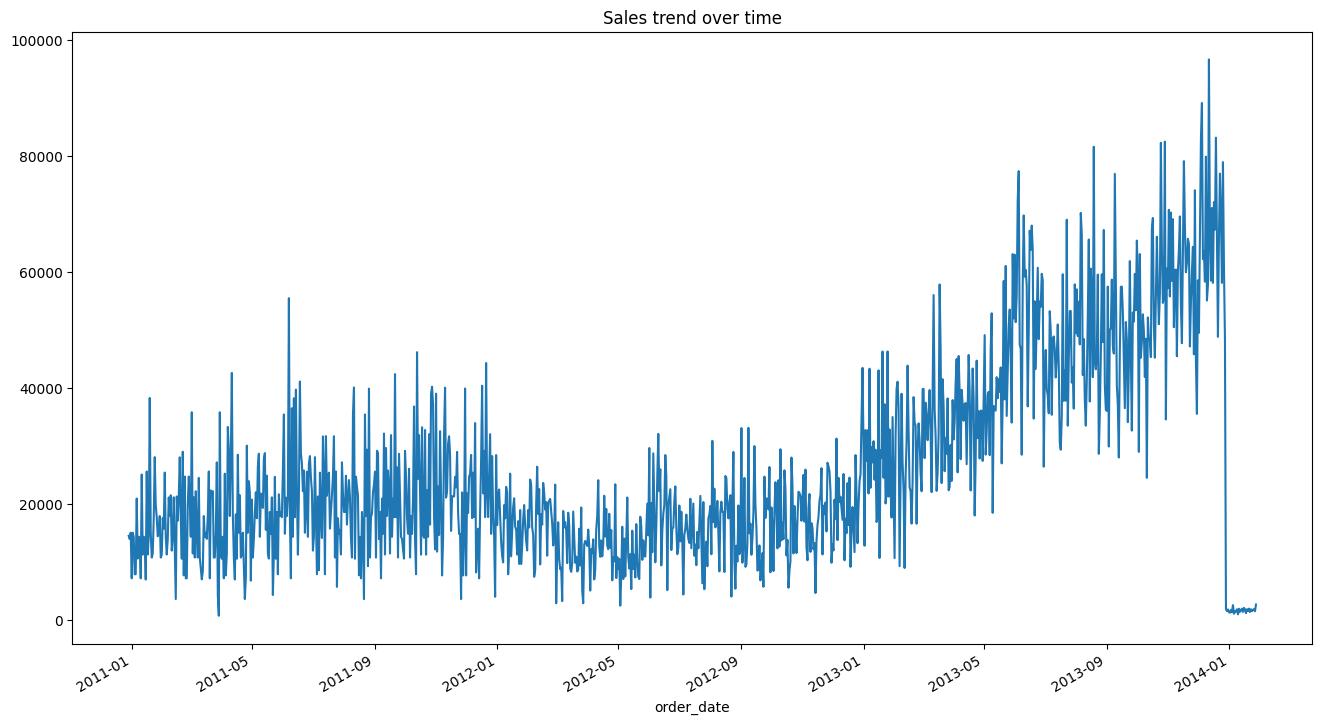

In [59]:
sales_trend = df.groupby('order_date')['sales_amount'].sum()
plt.figure(figsize=(16,9))
sales_trend.plot()
plt.title("Sales trend over time")
plt.show()

In [61]:
monthly_sales = df.groupby('month')['sales_amount'].sum()
monthly_sales

month
1.0     1868558
2.0     1744517
3.0     1908375
4.0     1948226
5.0     2204969
6.0     2935883
7.0     2412838
8.0     2684313
9.0     2536520
10.0    2916550
11.0    2979113
12.0    3211396
Name: sales_amount, dtype: int64

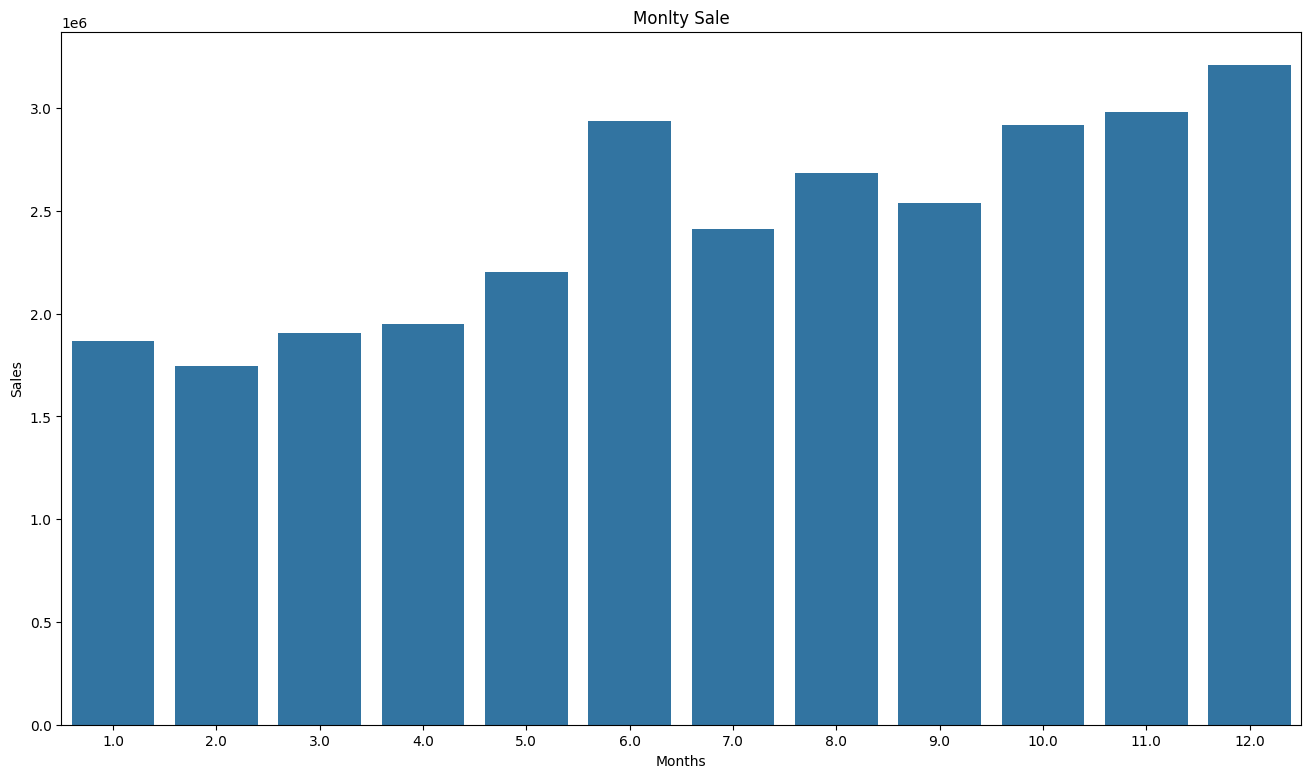

In [62]:
monthly_sales = df.groupby('month')['sales_amount'].sum()
plt.figure(figsize=(16,9))
sns.barplot(x=monthly_sales.index,y=monthly_sales.values)
plt.xlabel("Months")
plt.ylabel("Sales")
plt.title("Monlty Sale")
plt.show()

Revenue By product Category

In [63]:
category_sales = df.groupby('category')['sales_amount'].sum().sort_values()
category_sales

category
Clothing         339716
Accessories      700262
Bikes          28316272
Name: sales_amount, dtype: int64

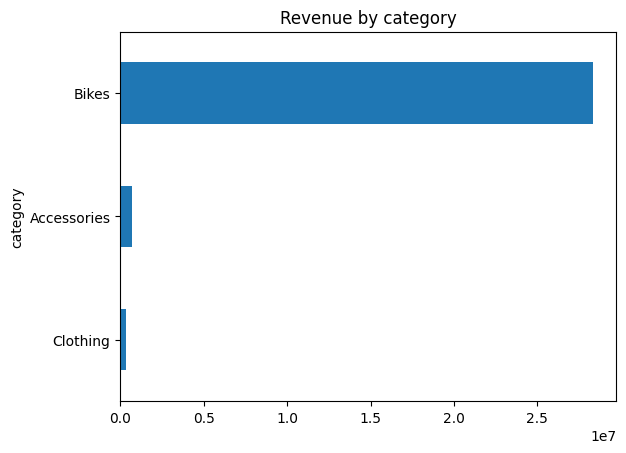

In [64]:
category_sales.plot(kind='barh')
plt.title("Revenue by category")
plt.show()

top 10 products

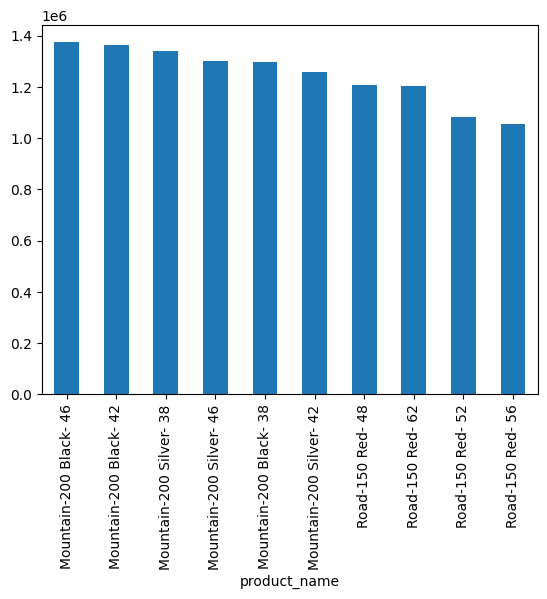

In [66]:
top_products = df.groupby('product_name')['sales_amount'].sum().nlargest(10)
top_products.plot(kind='bar')
plt.show()